In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import warnings
from numpy import trapz
from tqdm import tqdm

# --- Global Setup & Style ---
plt.style.use('halfstyle.mplstyle')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# --- Model & Data Parameters ---
C0, C1, OFFSET = 0.1, 0.04, 8
P_X_LOC, P_X_SCALE = 0, 1

# --- Polynomial Model Parameters ---
POLY_DEGREE = 3  # Degree of the polynomial model (e.g., 3 for cubic)
TAU2_INTERCEPT = 1.0  # Prior variance for the intercept term (theta_0)
TAU2_COEFFS = 0.1     # Prior variance for all other coefficients (theta_1, theta_2, ...)

# --- Main Experiment Setup ---
data_sizes = [i for i in range(POLY_DEGREE + 1, 11)] + [20, 30, 40, 50, 100, 200, 300]
num_trials = 100 # paper uses 3000

num_params = POLY_DEGREE + 1
prior_variances = [TAU2_INTERCEPT] + [TAU2_COEFFS] * POLY_DEGREE
PRIOR_MEAN = np.zeros(num_params)
PRIOR_COV = np.diag(prior_variances)

def create_polynomial_features(x, degree):
    """
    Creates a design matrix with polynomial features of a given degree.
    Input x is a 1D array. Output is a 2D array where each row is [1, x, x^2, ..., x^degree].
    """
    x = np.atleast_1d(x)
    # This creates columns [x^0, x^1, x^2, ...] using broadcasting
    X_design = np.power(x.reshape(-1, 1), np.arange(degree + 1))
    return X_design

def true_mean_func(x, k_true):
    """Calculates the true mean based on the true polynomial coefficients (k_true)."""
    x = np.atleast_1d(x)
    degree = len(k_true) - 1
    X_design = create_polynomial_features(x, degree)
    return X_design @ k_true

def aleatoric_variance_func(x, c0=C0, c1=C1, offset=OFFSET):
    """Aleatoric noise is independent of the model complexity."""
    return c0 + c1 * (x + offset)**2

def get_posterior(X_features, y_observations):
    """Calculates the posterior for the polynomial coefficients."""
    degree = len(PRIOR_MEAN) - 1
    X_design = create_polynomial_features(X_features, degree)
    
    Sigma_prior_inv = np.linalg.inv(PRIOR_COV)
    sigma2_obs = aleatoric_variance_func(X_features)
    S_inv_diag = 1.0 / sigma2_obs
    
    XT_S_inv_X = (X_design.T * S_inv_diag) @ X_design
    XT_S_inv_y = (X_design.T * S_inv_diag) @ y_observations
    
    Sigma_post = np.linalg.inv(Sigma_prior_inv + XT_S_inv_X)
    mu_post = Sigma_post @ XT_S_inv_y
    return mu_post, Sigma_post

def predictive_mean_func(x, mu_post):
    """Calculates the predictive mean using the posterior mean of the coefficients."""
    x = np.atleast_1d(x)
    degree = len(mu_post) - 1
    X_design = create_polynomial_features(x, degree)
    return X_design @ mu_post

def epistemic_variance_func(x, Sigma_post):
    """Calculates the epistemic variance from the posterior covariance of the coefficients."""
    x = np.atleast_1d(x)
    degree = Sigma_post.shape[0] - 1
    X_design = create_polynomial_features(x, degree)
    return np.sum((X_design @ Sigma_post) * X_design, axis=1)

def total_variance_func(x, Sigma_post):
    return epistemic_variance_func(x, Sigma_post) + aleatoric_variance_func(x)

def conditional_regret_func(x, mu_post, k_true):
    """Calculates conditional regret for a given set of true coefficients k_true."""
    return (true_mean_func(x, k_true) - predictive_mean_func(x, mu_post))**2

def conditional_risk_func(x, mu_post, k_true):
    """Calculates conditional risk for a given set of true coefficients k_true."""
    return conditional_regret_func(x, mu_post, k_true) + aleatoric_variance_func(x)

def calculate_metric_coverage_curve(uncertainty_func, metric_func, p_x_dist):
    integration_grid = np.linspace(p_x_dist.mean() - 5 * p_x_dist.std(),
                                   p_x_dist.mean() + 5 * p_x_dist.std(), 5000)
    dx = integration_grid[1] - integration_grid[0]
    
    uncertainty_vals = uncertainty_func(integration_grid)
    metric_vals = metric_func(integration_grid)
    p_x_vals = p_x_dist.pdf(integration_grid)
    
    sorted_indices = np.argsort(uncertainty_vals)
    sorted_p_x, sorted_metric = p_x_vals[sorted_indices], metric_vals[sorted_indices]
    
    cumulative_coverage = np.cumsum(sorted_p_x * dx)
    cumulative_weighted_metric = np.cumsum(sorted_metric * sorted_p_x * dx)
    
    valid_mask = cumulative_coverage > 1e-9
    coverages = cumulative_coverage[valid_mask]
    average_metrics = cumulative_weighted_metric[valid_mask] / cumulative_coverage[valid_mask]
    
    return np.insert(coverages, 0, 0), np.insert(average_metrics, 0, np.nan)

# Data structures to store raw AUCs from all trials
results_regret = {strat: [] for strat in ["Aleatoric", "Epistemic", "Total"]}
results_risk = {strat: [] for strat in ["Aleatoric", "Epistemic", "Total"]}

p_x_distribution = norm(loc=P_X_LOC, scale=P_X_SCALE)

# --- Bayes Optimal Calculation ---
bayes_optimal_cov, bayes_optimal_risk = calculate_metric_coverage_curve(
    aleatoric_variance_func, aleatoric_variance_func, p_x_distribution
)
bayes_optimal_risk_auc = trapz(np.nan_to_num(bayes_optimal_risk), bayes_optimal_cov)

# --- MAIN EXPERIMENT LOOP ---
for n_samples in tqdm(data_sizes):
    print(f"Running simulations for data size = {n_samples}...")

    session_regret_aucs = {strat: [] for strat in ["Aleatoric", "Epistemic", "Total"]}
    session_risk_aucs = {strat: [] for strat in ["Aleatoric", "Epistemic", "Total"]}

    # Ensure n_samples is sufficient for the number of model parameters
    if n_samples < num_params:
        warnings.warn(f"Skipping n_samples={n_samples} as it's less than num_params={num_params}")
        for strat in ["Aleatoric", "Epistemic", "Total"]:
            results_regret[strat].append([np.nan] * num_trials)
            results_risk[strat].append([np.nan] * num_trials)
        continue

    for seed in range(num_trials, 2*num_trials):
        np.random.seed(seed)
        # Sample a "true" polynomial function from the prior
        k_true_sample = np.random.multivariate_normal(PRIOR_MEAN, PRIOR_COV)
        
        # Generate data from this true function
        X_features = np.random.normal(loc=P_X_LOC, scale=P_X_SCALE, size=n_samples)
        y_observations = true_mean_func(X_features, k_true_sample) + np.random.normal(0, np.sqrt(aleatoric_variance_func(X_features)))
        
        # Perform Bayesian inference to get the posterior
        mu_post, Sigma_post = get_posterior(X_features, y_observations)

        # Define the specific functions for this trial
        aleatoric_f = aleatoric_variance_func
        epistemic_f = lambda x: epistemic_variance_func(x, Sigma_post)
        total_f = lambda x: total_variance_func(x, Sigma_post)
        regret_f = lambda x: conditional_regret_func(x, mu_post, k_true_sample)
        risk_f = lambda x: conditional_risk_func(x, mu_post, k_true_sample)

        # Calculate AUCs for regret and risk for each uncertainty strategy
        for name, uncert_f in zip(["Aleatoric", "Epistemic", "Total"], [aleatoric_f, epistemic_f, total_f]):
            cov, reg = calculate_metric_coverage_curve(uncert_f, regret_f, p_x_distribution)
            session_regret_aucs[name].append(trapz(np.nan_to_num(reg), cov))
            
            cov, risk = calculate_metric_coverage_curve(uncert_f, risk_f, p_x_distribution)
            session_risk_aucs[name].append(trapz(np.nan_to_num(risk), cov))

    # Store the list of raw AUCs for this data size
    for strat in ["Aleatoric", "Epistemic", "Total"]:
        results_regret[strat].append(session_regret_aucs[strat])
        results_risk[strat].append(session_risk_aucs[strat])

print("All simulations complete.")

/tmp/ipykernel_83024/534706411.py:123: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  bayes_optimal_risk_auc = trapz(np.nan_to_num(bayes_optimal_risk), bayes_optimal_cov)
  0%|                                                                                                                                                   | 0/14 [00:00<?, ?it/s]/tmp/ipykernel_83024/534706411.py:162: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  session_regret_aucs[name].append(trapz(np.nan_to_num(reg), cov))
/tmp/ipykernel_83024/534706411.py:165: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  session_risk_aucs[name].append(trapz(np.nan_to_num(risk), cov))


Running simulations for data size = 4...


  7%|█████████▉                                                                                                                                 | 1/14 [00:01<00:16,  1.28s/it]

Running simulations for data size = 5...


 14%|███████████████████▊                                                                                                                       | 2/14 [00:02<00:14,  1.22s/it]

...

Running simulations for data size = 200...


 93%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏         | 13/14 [00:14<00:01,  1.10s/it]

Running simulations for data size = 300...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:15<00:00,  1.10s/it]

All simulations complete.


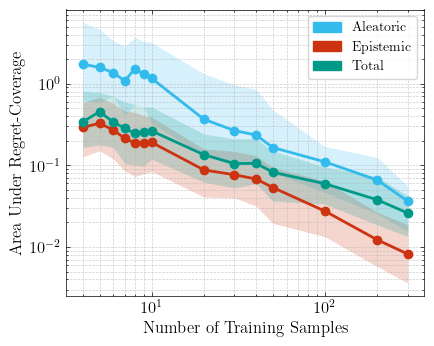

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = [colors[2], colors[4], colors[5]]

fig, ax = plt.subplots()

# Define the quantiles for the confidence interval
q_lower, q_upper = 25, 75

# Plot AUReC vs. Data Size with Quantiles
for i, strat in enumerate(["Aleatoric", "Epistemic", "Total"]):
    all_aucs = results_regret[strat]
    medians = np.array([np.median(aucs) for aucs in all_aucs])
    lower_bounds = np.array([np.percentile(aucs, q_lower) for aucs in all_aucs])
    upper_bounds = np.array([np.percentile(aucs, q_upper) for aucs in all_aucs])
    
    ax.plot(data_sizes, medians, marker='o', linestyle='-', color=colors[i])
    ax.fill_between(data_sizes, lower_bounds, upper_bounds, color=colors[i], alpha=0.2, linewidth=0)

# Plot AURiC vs. Data Size with Quantiles
"""
for i, strat in enumerate(["Aleatoric", "Epistemic", "Total"]):
    all_aucs = results_risk[strat]
    medians = np.array([np.median(aucs) for aucs in all_aucs])
    lower_bounds = np.array([np.percentile(aucs, q_lower) for aucs in all_aucs])
    upper_bounds = np.array([np.percentile(aucs, q_upper) for aucs in all_aucs])
    
    ax.plot(data_sizes, medians, marker='x', linestyle=':', color=colors[i])
    ax.fill_between(data_sizes, lower_bounds, upper_bounds, color=colors[i], alpha=0.2, linewidth=0)

ax.axhline(y=bayes_optimal_risk_auc, color='black', linestyle=':', lw=2)
"""

# Create proxy artists for line styles and markers
regret_line = mlines.Line2D([], [], color='gray', marker='o', linestyle='-', label='Regret')
risk_line = mlines.Line2D([], [], color='gray', marker='x', linestyle=':', label='Risk')

# Create proxy artists for colors
aleatoric_patch = mpatches.Patch(color=colors[0], label='Aleatoric')
epistemic_patch = mpatches.Patch(color=colors[1], label='Epistemic')
total_patch = mpatches.Patch(color=colors[2], label='Total')

# Combine handles and create the legend
handles = [aleatoric_patch, epistemic_patch, total_patch]
ax.legend(handles=handles, ncol=1, fontsize=10, loc="upper right")#, bbox_to_anchor=[0.0, 0.99])

ax.set_xlabel('Number of Training Samples')
ax.set_ylabel('Area Under Regret-Coverage')
ax.grid(True, which="both", ls="--", alpha=0.6)

plt.yscale("log")
plt.xscale("log")
plt.tight_layout()
plt.savefig("synthetic_experiment.pdf", dpi=500, bbox_inches="tight")
plt.show()